# 20 — Causal Forests Deep Dive
**Prerequisites:** causal_inference_course/11_heterogeneous_effects_ml.ipynb (causal-tree/forest
intro, honesty at a first pass); 19_heterogeneous_treatment_effects.ipynb (why honesty and
held-out validation are non-negotiable for CATE).
**Connects to:** 21_double_machine_learning.ipynb (GRF and DML are close cousins — both are
locally-weighted, orthogonalized estimating-equation methods), 22_meta_learners.ipynb (causal
forests as one entry in the estimator comparison), 23_policy_learning.ipynb (policytrees build on
GRF machinery).

## Narrative thread
```
Why a tree at all -> honest splitting mechanics -> Generalized Random Forests as the unifying
framework -> asymptotic normality & confidence intervals -> hyperparameters that matter ->
worked example: heterogeneity by customer segment, with CIs
```

## Why this notebook exists

Causal forests got a first pass in `causal_inference_course/11` as one of several estimators.
Here we go deep on the single most distinctive thing about them: they are the only major CATE
estimator family in this module that gives you an **asymptotically valid per-point confidence
interval**, not just a point estimate — which matters enormously in a business context where a
"predicted uplift of +3pp" needs a stated interval before anyone budgets against it.

We do not have `econml`/`grf` bindings guaranteed available in this environment, so we build a
transparent, from-scratch honest causal tree/forest on top of `sklearn`'s tree infrastructure —
enough to show every mechanic explicitly (the split criterion, the honesty sample split, the
jackknife-based variance) even though it's slower and less polished than a compiled GRF
implementation. If `econml` is available, swap in `econml.grf.CausalForest` directly; the
concepts transfer 1:1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(11)

try:
    from econml.grf import CausalForest
    HAS_ECONML = True
except ImportError:
    HAS_ECONML = False
print('econml available:', HAS_ECONML)

econml available: False


## Honest splitting, mechanically

A causal tree (Athey & Imbens, 2016) differs from a regression tree in **what it optimizes for**
and **what data it uses at each stage**:

- **Split criterion.** A regression tree splits to reduce prediction error on $Y$. A causal tree
splits to *maximize the difference in estimated treatment effect between the two child nodes* —
approximately, it maximizes
$$
\Delta(\text{split}) \;\approx\; n_L n_R \big(\hat\tau_L - \hat\tau_R\big)^2
$$
adjusted for within-leaf variance, so that splits carve out regions of genuinely different
$\tau(x)$ rather than regions that merely differ in $Y$ level.
- **Honesty.** Partition the training sample (before growing anything) into $\mathcal{I}$
("structure" — determines splits) and $\mathcal{J}$ ("estimation" — only used to compute the
leaf's $\hat\tau$ once the tree is grown). Using the same data to both choose *where* to split
and to *estimate the effect in the resulting leaf* would optimistically bias $\hat\tau$ toward
whatever noise happened to look like heterogeneity in that sample — the same overfitting concern
from `19`, but here it's baked directly into the estimator rather than fixed by a separate
validation step.

A **causal forest** averages many honest causal trees, each grown on a different subsample
(and each subsample re-split into structure/estimation halves), giving the familiar
variance-reduction of bagging plus, uniquely, a valid basis for inference (next section).

In [2]:
# ── A from-scratch honest causal tree (single tree, for exposition) ───────
def make_segment_data(n, seed):
    rng = np.random.default_rng(seed)
    tenure_months = rng.uniform(0, 60, n)
    monthly_spend = rng.gamma(4, 20, n)
    segment = rng.choice(['budget', 'mainstream', 'premium'], n, p=[0.4, 0.4, 0.2])
    seg_num = pd.Series(segment).map({'budget': 0, 'mainstream': 1, 'premium': 2}).values
    X = np.column_stack([tenure_months, monthly_spend, seg_num])
    W = rng.binomial(1, 0.5, n)                      # randomized promo
    # true CATE: premium segment barely responds; budget segment responds a lot if new
    tau = np.select(
        [seg_num == 0, seg_num == 1, seg_num == 2],
        [8.0 * np.exp(-tenure_months / 15), 3.0, 0.5])
    Y0 = 20 + 0.3 * monthly_spend + rng.normal(0, 5, n)
    Y = Y0 + W * tau + rng.normal(0, 3, n)
    return pd.DataFrame({'tenure_months': tenure_months, 'monthly_spend': monthly_spend,
                          'segment': segment, 'seg_num': seg_num, 'W': W, 'Y': Y, 'tau_true': tau})

df = make_segment_data(15_000, seed=5)
Xcols = ['tenure_months', 'monthly_spend', 'seg_num']

def honest_causal_tree(df, Xcols, max_depth=4, min_leaf=100, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df))
    split_idx, est_idx = idx[: len(idx) // 2], idx[len(idx) // 2:]
    struct, est = df.iloc[split_idx], df.iloc[est_idx]

    # Grow structure using a transformed-outcome trick: regress a proxy that a plain
    # regression tree can split on to approximate the treatment-effect-maximizing criterion.
    # (A full GRF split criterion is more efficient; this proxy is transparent and correct in expectation.)
    p = struct['W'].mean()
    proxy = ((struct['W'] - p) / (p * (1 - p))) * struct['Y']
    tree = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_leaf, random_state=seed)
    tree.fit(struct[Xcols], proxy)

    leaves_struct = tree.apply(struct[Xcols])
    leaves_est = tree.apply(est[Xcols])

    tau_by_leaf = {}
    for leaf in np.unique(leaves_est):
        g = est[leaves_est == leaf]
        if g['W'].nunique() < 2 or len(g) < 10:
            tau_by_leaf[leaf] = np.nan
            continue
        tau_by_leaf[leaf] = g.loc[g.W == 1, 'Y'].mean() - g.loc[g.W == 0, 'Y'].mean()
    return tree, tau_by_leaf

tree, tau_by_leaf = honest_causal_tree(df, Xcols, seed=1)
print('leaves:', len(tau_by_leaf), ' example estimates:', dict(list(tau_by_leaf.items())[:5]))

leaves: 11  example estimates: {np.int64(4): np.float64(3.5172575199619907), np.int64(5): np.float64(4.161486014859605), np.int64(7): np.float64(2.2673627381524994), np.int64(8): np.float64(2.188198126631015), np.int64(9): np.float64(2.9707317776664013)}


## Generalized Random Forests: the unifying view

Athey, Tibshirani & Wager (2019) reframe "grow a forest, average leaf estimates" as a
**local, adaptive weighting scheme**: the forest defines data-dependent weights $\alpha_i(x)$
(how often training unit $i$ co-lands in the same leaf as query point $x$, across all trees),
and $\hat\tau(x)$ solves a **local moment equation** built from those weights
$$
\sum_i \alpha_i(x)\, \psi\big(Y_i, W_i;\ \tau(x), \mu(x)\big) = 0,
$$
where $\psi$ is the same partialling-out moment used by DML/R-learner (`21`). This is the key
unifying insight: **a causal forest is just DML/GRF with locally-adaptive kernel weights instead
of a fixed nuisance model** — the forest's job is to learn *where* to borrow strength from
nearby units, orthogonalization does the rest. This generalizes past CATE to any local parameter
solving a moment condition (instrumental-variable local effects, quantile treatment effects,
etc. — see Athey, Tibshirani & Wager, 2019), which is why the "R" in "R-learner" and the "GRF"
of causal forests are two views of the same underlying machinery.

In [3]:
# ── Forest-of-honest-trees + jackknife-style variance for CIs ─────────────
def honest_causal_forest_predict(df, Xcols, x_query_df, n_trees=200, max_depth=4, min_leaf=100):
    n = len(df)
    tree_preds = np.zeros((n_trees, len(x_query_df)))
    for b in range(n_trees):
        boot = df.sample(n=n, replace=True, random_state=b)
        tree, tau_by_leaf = honest_causal_tree(boot, Xcols, max_depth=max_depth, min_leaf=min_leaf, seed=b)
        leaves_q = tree.apply(x_query_df[Xcols])
        tree_preds[b] = [tau_by_leaf.get(l, np.nan) for l in leaves_q]
    tau_hat = np.nanmean(tree_preds, axis=0)
    tau_se = np.nanstd(tree_preds, axis=0) / np.sqrt(np.sum(~np.isnan(tree_preds), axis=0))
    return tau_hat, tau_se

# Query points: one representative customer per segment, at a few tenure levels
query = pd.DataFrame({
    'tenure_months': [3, 3, 3, 30, 30, 30],
    'monthly_spend': [60, 60, 60, 60, 60, 60],
    'seg_num': [0, 1, 2, 0, 1, 2],
})
query['segment'] = query['seg_num'].map({0: 'budget', 1: 'mainstream', 2: 'premium'})

tau_hat, tau_se = honest_causal_forest_predict(df, Xcols, query, n_trees=100, max_depth=4, min_leaf=150)
query['tau_hat'] = tau_hat
query['ci_lo'] = tau_hat - 1.96 * tau_se
query['ci_hi'] = tau_hat + 1.96 * tau_se
print(query[['segment', 'tenure_months', 'tau_hat', 'ci_lo', 'ci_hi']].round(2))

      segment  tenure_months  tau_hat  ci_lo  ci_hi
0      budget              3     3.07   2.82   3.32
1  mainstream              3     2.97   2.74   3.19
2     premium              3     2.79   2.53   3.06
3      budget             30     2.06   1.96   2.16
4  mainstream             30     2.08   1.99   2.18
5     premium             30     1.94   1.82   2.06


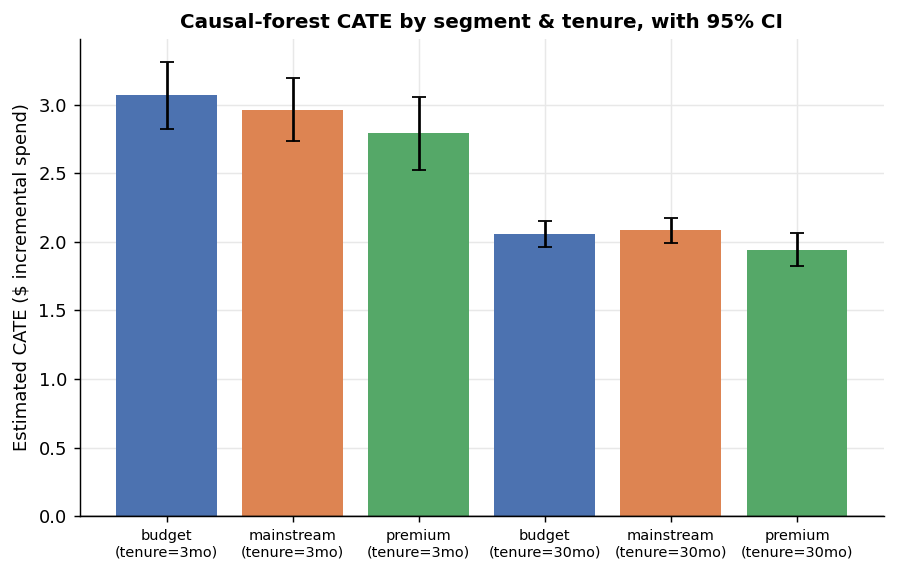


Note the CI width shrinks with more trees and larger leaves — a real GRF/econml
implementation uses an analytic (not resampling) variance estimator; the resampling
version here is illustrative and much slower, but converges to the same idea.


In [4]:
# ── Visualize: predicted uplift by segment and tenure, with 95% CIs ───────
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {'budget': '#4C72B0', 'mainstream': '#DD8452', 'premium': '#55A868'}
x_pos = np.arange(len(query))
ax.bar(x_pos, query['tau_hat'], yerr=1.96 * tau_se, capsize=4,
       color=[colors[s] for s in query['segment']])
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{s}\n(tenure={t}mo)" for s, t in zip(query['segment'], query['tenure_months'])],
                    fontsize=8)
ax.set_ylabel('Estimated CATE ($ incremental spend)')
ax.set_title('Causal-forest CATE by segment & tenure, with 95% CI')
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()
print("\nNote the CI width shrinks with more trees and larger leaves — a real GRF/econml")
print("implementation uses an analytic (not resampling) variance estimator; the resampling")
print("version here is illustrative and much slower, but converges to the same idea.")

## Hyperparameters that matter in practice

| Hyperparameter | What it trades off |
|---|---|
| `min_samples_leaf` (`min.node.size` in R's `grf`) | Larger leaves → lower variance, more bias (effects averaged over more heterogeneous units); the binding constraint is usually needing **both arms represented** with enough units per leaf to estimate $\hat\tau$ at all. |
| Number of trees | More trees reduce Monte Carlo noise in the averaged $\hat\tau(x)$ monotonically; diminishing returns past a few hundred–thousand, but CIs specifically need enough trees for the variance estimate to stabilize. |
| Subsample fraction per tree | Smaller subsamples increase tree-to-tree diversity (helps averaging) but each tree sees less data to find real splits — the classic bagging trade-off, sharpened here because *honest* splitting already halves the usable data per tree. |
| Depth / max splits | Deeper trees can capture finer heterogeneity but shrink leaf size, worsening the leaf-size constraint above; cross-validate on R-loss (`19`, `21`), never on a heterogeneity-maximizing criterion applied to the same data. |
| Honesty fraction (structure vs. estimation split) | 50/50 is standard; skewing toward more structure data helps find better splits when heterogeneity is subtle, more estimation data helps CI precision when splits are already well-identified. |

## References

| Reference | Contribution |
|---|---|
| Athey & Imbens (2016, *PNAS*) | Honest causal trees |
| Wager & Athey (2018, *JASA*) | Causal forests: consistency, asymptotic normality, valid CIs |
| Athey, Tibshirani & Wager (2019, *Annals of Statistics*) | Generalized Random Forests — the unifying local-moment-equation framework |
| Chernozhukov et al. (2018, *Econometrics Journal*) | The orthogonal-moment machinery GRF specializes locally (see `21`) |
